In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [9]:
# Install required libraries
!pip install torch numpy matplotlib seaborn -q

# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Print info
print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device available: {'GPU' if torch.cuda.is_available() else 'CPU'}")

All imports successful!
PyTorch version: 2.10.0+cpu
Device available: CPU


In [10]:
import numpy as np

W_x = 0.8
W_h = 0.5
b   = 0.1
h0  = 0.0
x1  = 1.0
x2  = 0.5

# Calculate h1
h1 = np.tanh(W_h * h0 + W_x * x1 + b)

# Calculate h2
h2 = np.tanh(W_h * h1 + W_x * x2 + b)

print(f"h1 = {h1}")
print(f"h2 = {h2}")

h1 = 0.7162978701990245
h2 = 0.695302727644787


In [11]:
rnn = nn.RNN(input_size=5, hidden_size=8, num_layers=1, batch_first=True)

# Fake input: batch_size=2, sequence_length=6, input_size=5
x  = torch.randn(2, 6, 5)
h0 = torch.zeros(1, 2, 8)   # (num_layers, batch_size, hidden_size)

output, h_n = rnn(x, h0)

print("Input shape:         ", x.shape)
print("Initial hidden shape:", h0.shape)
print("Output shape:        ", output.shape, "  ← hidden state at every time step")
print("Final hidden shape:  ", h_n.shape,   "  ← hidden state at last time step only")
print()
print("output[:, -1, :] == h_n[0]:", torch.allclose(output[:, -1, :], h_n[0]))
     

Input shape:          torch.Size([2, 6, 5])
Initial hidden shape: torch.Size([1, 2, 8])
Output shape:         torch.Size([2, 6, 8])   ← hidden state at every time step
Final hidden shape:   torch.Size([1, 2, 8])   ← hidden state at last time step only

output[:, -1, :] == h_n[0]: True


In [12]:
import torch
import torch.nn as nn

class SimpleRNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleRNNClassifier, self).__init__()
        
        # RNN layer
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch, seq_len, input_size)
        
        batch_size = x.size(0)
        
        # Initialize hidden state
        h0 = torch.zeros(1, batch_size, self.rnn.hidden_size)
        
        # Pass through RNN
        output, h_n = self.rnn(x, h0)
        
        # Take final hidden state
        final_hidden = h_n[0]   # shape: (batch, hidden_size)
        
        # Pass through FC layer
        out = self.fc(final_hidden)
        
        return out

In [13]:
model = SimpleRNNClassifier(10, 16, 2)
test_input = torch.randn(4, 7, 10)

output = model(test_input)
print(output.shape)

torch.Size([4, 2])


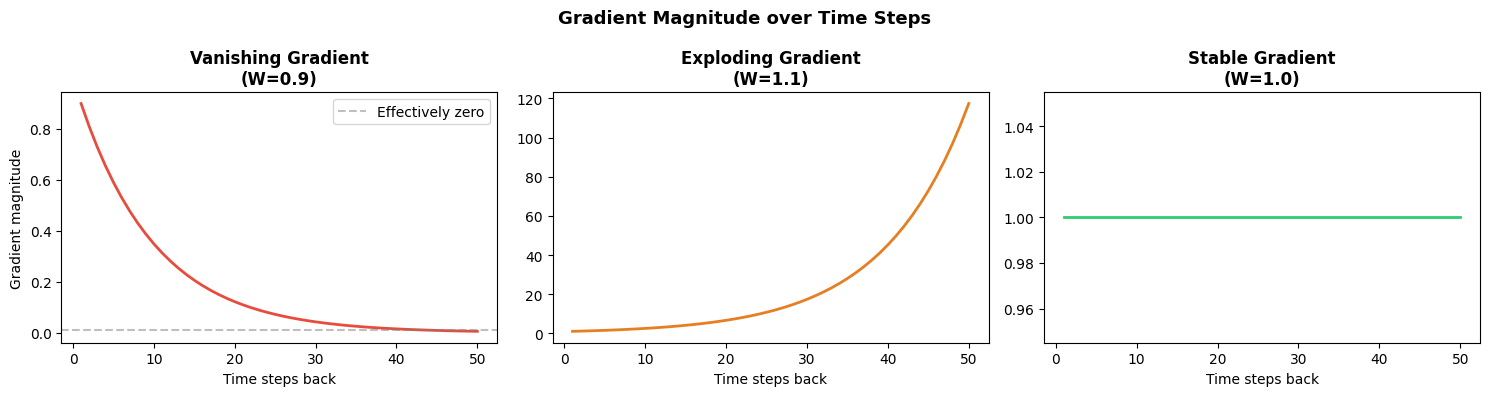

In [14]:
steps = np.arange(1, 51)

w_vanish  = 0.9  # |W| < 1 → gradients shrink
w_explode = 1.1  # |W| > 1 → gradients grow
w_good    = 1.0  # |W| = 1 → gradients stable (rare in practice)

grad_vanish  = w_vanish  ** steps
grad_explode = np.clip(w_explode ** steps, 0, 1e6)  # clip for display
grad_good    = w_good    ** steps

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(steps, grad_vanish, color='#e74c3c', linewidth=2)
axes[0].set_title('Vanishing Gradient\n(W=0.9)', fontweight='bold')
axes[0].set_xlabel('Time steps back')
axes[0].set_ylabel('Gradient magnitude')
axes[0].axhline(y=0.01, color='gray', linestyle='--', alpha=0.5, label='Effectively zero')
axes[0].legend()

axes[1].plot(steps, grad_explode, color='#e67e22', linewidth=2)
axes[1].set_title('Exploding Gradient\n(W=1.1)', fontweight='bold')
axes[1].set_xlabel('Time steps back')

axes[2].plot(steps, grad_good, color='#2ecc71', linewidth=2)
axes[2].set_title('Stable Gradient\n(W=1.0)', fontweight='bold')
axes[2].set_xlabel('Time steps back')

plt.suptitle('Gradient Magnitude over Time Steps', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
     


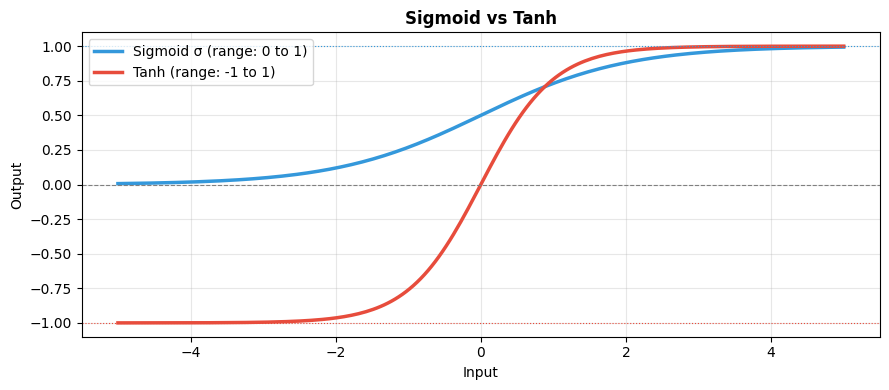

Sigmoid at 0: 0.5  → gates start at 0.5 (neutral)
Tanh    at 0: 0.0     → candidate values centered at 0


In [15]:
x = np.linspace(-5, 5, 200)
sigmoid = 1 / (1 + np.exp(-x))
tanh    = np.tanh(x)

plt.figure(figsize=(9, 4))
plt.plot(x, sigmoid, color='#3498db', linewidth=2.5, label='Sigmoid σ (range: 0 to 1)')
plt.plot(x, tanh,    color='#e74c3c', linewidth=2.5, label='Tanh (range: -1 to 1)')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.axhline(1, color='#3498db', linewidth=0.8, linestyle=':')
plt.axhline(-1, color='#e74c3c', linewidth=0.8, linestyle=':')
plt.xlabel('Input')
plt.ylabel('Output')
plt.title('Sigmoid vs Tanh', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Sigmoid at 0:", round(1/(1+np.exp(0)), 3),  " → gates start at 0.5 (neutral)")
print("Tanh    at 0:", round(np.tanh(0), 3), "    → candidate values centered at 0")
     

In [16]:
import torch
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(LSTMClassifier, self).__init__()
        
        # LSTM layer
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )
        
        # Fully connected layer
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        batch_size = x.size(0)
        
        # Initialize hidden state and cell state
        h0 = torch.zeros(1, batch_size, self.lstm.hidden_size).to(x.device)
        c0 = torch.zeros(1, batch_size, self.lstm.hidden_size).to(x.device)
        
        # Forward pass through LSTM
        output, (h_n, c_n) = self.lstm(x, (h0, c0))
        
        # Take final hidden state
        final_hidden = h_n[-1]
        
        # Pass through fully connected layer
        out = self.fc(final_hidden)
        
        return out

In [17]:
lstm_model = LSTMClassifier(input_size=10, hidden_size=16, num_classes=3)
test_input = torch.randn(4, 7, 10)

output = lstm_model(test_input)
print("Output shape:", output.shape)
print("✅ Correct!" if output.shape == (4, 3) else "❌ Check your code")

Output shape: torch.Size([4, 3])
✅ Correct!


In [18]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Create models
rnn_clf = SimpleRNNClassifier(input_size=10, hidden_size=32, num_classes=2)
lstm_clf = LSTMClassifier(input_size=10, hidden_size=32, num_classes=2)

# Print counts
print(f"RNN parameters: {count_parameters(rnn_clf):,}")
print(f"LSTM parameters: {count_parameters(lstm_clf):,}")
print(f"Ratio (LSTM/RNN): {count_parameters(lstm_clf)/count_parameters(rnn_clf):.2f}x")

RNN parameters: 1,474
LSTM parameters: 5,698
Ratio (LSTM/RNN): 3.87x


In [19]:
import torch
import torch.nn as nn

class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(GRUClassifier, self).__init__()

        # GRU layer
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        # Fully connected layer
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        batch_size = x.size(0)

        # Initialize hidden state
        h0 = torch.zeros(1, batch_size, self.gru.hidden_size).to(x.device)

        # Forward pass through GRU
        output, h_n = self.gru(x, h0)

        # Take final hidden state
        final_hidden = h_n[-1]

        # Classification
        out = self.fc(final_hidden)

        return out


# Test
test_input = torch.randn(4, 7, 10)
gru_model = GRUClassifier(input_size=10, hidden_size=16, num_classes=3)

output = gru_model(test_input)
print("Output shape:", output.shape)
print("✅ Correct!" if output.shape == (4, 3) else "❌ Check your code")

Output shape: torch.Size([4, 3])
✅ Correct!


| Feature                         | RNN                           | LSTM                                 | GRU                                            |
| ------------------------------- | ----------------------------- | ------------------------------------ | ---------------------------------------------- |
| **Number of gates**             | 0                             | 3 (forget, input, output)            | 2 (update, reset)                              |
| **Number of states (h, c)**     | 1 (h only)                    | 2 (h and c)                          | 1 (h only)                                     |
| **Handles long dependencies?**  | ❌ Poor                        | ✅ Very good                          | ✅ Good                                         |
| **Relative speed**              | ⚡ Fastest                     | 🐢 Slowest                           | ⚡⚡ Faster than LSTM                            |
| **When would you choose this?** | Simple tasks, short sequences | Long sequences, complex dependencies | Default choice, balance of speed + performance |


In [20]:
# ── STEP 1: Data Preparation ──────────────────────────────────────────────
# This cell is fully provided — read it and understand each part.

# Training text: Python function signatures (DocForge relevant!)
text = """
def calculate_area(radius):
def sort_list(items, reverse=False):
def read_file(filepath, encoding='utf-8'):
def find_max(numbers):
def merge_dicts(dict_a, dict_b):
def is_palindrome(string):
def count_words(text):
def format_output(data, indent=4):
def load_model(path, device='cpu'):
def tokenize_code(source, language='python'):
""".strip()

# Build character vocabulary
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Text length: {len(text)} characters")
print(f"Unique characters: {vocab_size}")
print(f"Characters: {''.join(chars)}")

# Create mappings
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# Encode entire text as integers
encoded = [char_to_idx[ch] for ch in text]
print(f"\nFirst 10 encoded: {encoded[:10]}")
print(f"Decoded back: {''.join([idx_to_char[i] for i in encoded[:10]])}")

Text length: 330 characters
Unique characters: 37
Characters: 
 '(),-48:=F_abcdefghiklmnoprstuvwxyz

First 10 encoded: [16, 17, 18, 1, 15, 13, 23, 15, 31, 23]
Decoded back: def calcul


In [21]:
# ── STEP 2: Create Training Sequences ─────────────────────────────────────
# Provided — read and understand

SEQ_LEN = 20  # length of each input sequence

def create_sequences(encoded_text, seq_len):
    """Create (input_sequence, target_sequence) pairs."""
    inputs, targets = [], []
    for i in range(len(encoded_text) - seq_len):
        inputs.append(encoded_text[i : i + seq_len])
        targets.append(encoded_text[i + 1 : i + seq_len + 1])  # shifted by 1
    return torch.tensor(inputs, dtype=torch.long), torch.tensor(targets, dtype=torch.long)

X, y = create_sequences(encoded, SEQ_LEN)
print(f"Input sequences shape:  {X.shape}")
print(f"Target sequences shape: {y.shape}")
print(f"\nExample:")
print(f"  Input:  {''.join([idx_to_char[i.item()] for i in X[0]])}")
print(f"  Target: {''.join([idx_to_char[i.item()] for i in y[0]])}")
     

Input sequences shape:  torch.Size([310, 20])
Target sequences shape: torch.Size([310, 20])

Example:
  Input:  def calculate_area(r
  Target: ef calculate_area(ra


In [22]:
import torch
import torch.nn as nn

class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_layers):
        super(CharLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # 🔹 1. Embedding layer (char index → vector)
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # 🔹 2. LSTM layer
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        # 🔹 3. Fully connected layer (hidden → vocab)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        # x shape: (batch_size, seq_len)

        # 🔹 Step 1: Embedding
        x = self.embedding(x)  
        # (batch, seq_len, embed_dim)

        # 🔹 Step 2: LSTM
        out, _ = self.lstm(x)  
        # (batch, seq_len, hidden_size)

        # 🔹 Step 3: Linear layer
        out = self.fc(out)  
        # (batch, seq_len, vocab_size)

        return out

In [23]:
EMBED_DIM = 32
HIDDEN_SIZE = 128
NUM_LAYERS = 2

char_model = CharLSTM(vocab_size, EMBED_DIM, HIDDEN_SIZE, NUM_LAYERS)

print(f"Model parameters: {count_parameters(char_model):,}")

# Quick shape check
test_out = char_model(X[:4])
print(f"Output shape: {test_out.shape}")  # should be (4, SEQ_LEN, vocab_size)
print("✅ Correct!" if test_out.shape == (4, SEQ_LEN, vocab_size) else "❌ Check your code")

Model parameters: 220,997
Output shape: torch.Size([4, 20, 37])
✅ Correct!


Epoch [ 10/80]  Loss: 0.2266
Epoch [ 20/80]  Loss: 0.1527
Epoch [ 30/80]  Loss: 0.1452
Epoch [ 40/80]  Loss: 0.1398
Epoch [ 50/80]  Loss: 0.1371
Epoch [ 60/80]  Loss: 0.1361
Epoch [ 70/80]  Loss: 0.1341
Epoch [ 80/80]  Loss: 0.1335


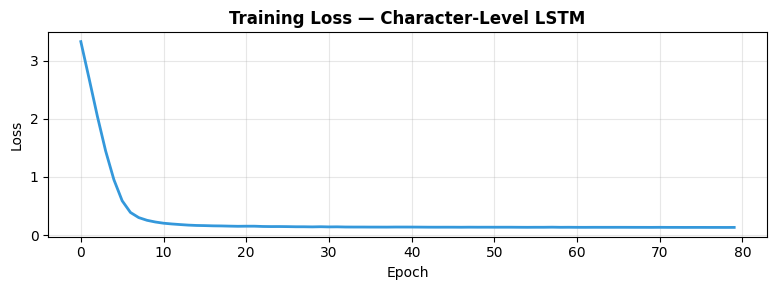

In [24]:
# ── STEP 4: Training Loop ─────────────────────────────────────────────────
# Provided — read and understand, then run.

from torch.utils.data import DataLoader, TensorDataset

EPOCHS     = 80
BATCH_SIZE = 32
LR         = 0.005

dataset    = TensorDataset(X, y)
loader     = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(char_model.parameters(), lr=LR)

loss_history = []

for epoch in range(EPOCHS):
    char_model.train()
    total_loss = 0
    for xb, yb in loader:
        optimizer.zero_grad()
        logits = char_model(xb)            # (batch, seq_len, vocab_size)
        # Reshape for CrossEntropyLoss: (batch*seq_len, vocab_size) vs (batch*seq_len,)
        loss   = criterion(logits.reshape(-1, vocab_size), yb.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(char_model.parameters(), 1.0)  # gradient clipping!
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}]  Loss: {avg_loss:.4f}")

# Plot training curve
plt.figure(figsize=(8, 3))
plt.plot(loss_history, color='#3498db', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss — Character-Level LSTM', fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
     

In [28]:
# ── STEP 5: Generate Text ──────────────────────────────────────────────────
# Provided — run after training

def generate_text(model, seed_text, length=80, temperature=0.8):
    """
    Generate text starting from seed_text.
    temperature: lower = more deterministic, higher = more random
    """
    model.eval()
    result = list(seed_text)
    input_seq = [char_to_idx.get(ch, 0) for ch in seed_text[-SEQ_LEN:]]

    with torch.no_grad():
        for _ in range(length):
            x_in  = torch.tensor([input_seq[-SEQ_LEN:]], dtype=torch.long)
            logits = model(x_in)[0, -1, :]  # last time step
            probs  = torch.softmax(logits / temperature, dim=0).numpy()
            next_idx = np.random.choice(len(probs), p=probs)
            result.append(idx_to_char[next_idx])
            input_seq.append(next_idx)

    return ''.join(result)

print("Generated text (seed='def '):")
print("-" * 50)
print(generate_text(char_model, "def ", length=100))
print("-" * 50)
print("\nGenerated text (seed='def load'):")
print("-" * 50)
print(generate_text(char_model, "def load", length=80))

Generated text (seed='def '):
--------------------------------------------------
def format_output(data, indent=4):
def load_model(path, device='cpu'):
def tokenize_code(source, languag
--------------------------------------------------

Generated text (seed='def load'):
--------------------------------------------------
def load_model(path, device='cpu'):
def tokenize_code(source, language='python'):
def to


1. Does the generated text look Python-like? What patterns did it learn?

Yes, the generated text partially looks Python-like.

The model learns:

The pattern def function_name(...):
Use of parentheses () and colons :
Common keywords like def, commas, underscores
Structure of function signatures

However:

Function names may be random or nonsensical
Arguments may not make logical sense
Syntax is approximate, not perfect

👉 Why?
Because it was trained on only ~10 examples → it learns structure, not meaning

2. What does clip_grad_norm_ do and why is it used?
torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

👉 It limits (clips) the gradient magnitude during backpropagation.

Why needed:
In RNN/LSTM → gradients can explode (become very large)
This makes training unstable
What it does:
If gradient norm > 1.0 → scale it down
If small → leave it unchanged

👉 Result:

Stable training
Prevents sudden huge updates

3. What does temperature do? (0.1 vs 2.0)

Temperature controls randomness in text generation.

🔹 Low temperature (0.1)
Very confident predictions
Repeats common patterns
Output = boring but correct

👉 Example:

def def def def calculate():
🔹 High temperature (2.0)
More randomness
Tries unusual characters
Output = creative but messy

👉 Example:

def zq_#@func(!!!):

4. What improves with more training data?

If trained on thousands of functions, then:

✅ Improvements:
Better syntax correctness
More realistic function names
Proper argument structures
Learns coding patterns deeply
Less random garbage output
❌ What still won’t be perfect:
Logical correctness (it’s not executing code)
Deep semantic understanding (limited)

✍️ R1 — Big Picture
Transformers process sequences differently from LSTMs because they do not rely on step-by-step memory. Instead, they use attention mechanisms to look at all parts of the sequence at once and decide which parts are important. This helps them capture long-range dependencies much better. LSTMs can struggle with very long sequences because information can fade over time, and Transformers fix this by directly connecting all positions in the sequence.

✍️ R2 — Honest Self-Assessment
The most confusing part of this worksheet was understanding how the LSTM processes sequences internally and how the outputs are reshaped during training. It was also difficult to fully grasp how probabilities are used to generate the next character in text generation. Before moving to Transformers, I would like to better understand how LSTMs maintain memory over time and how the training loop updates the model step by step.

✍️ R3 — Application
If I had to use an LSTM in the DocForge pipeline, I would use it for generating docstrings from code. I would train the model on pairs of function definitions and their corresponding docstrings so it can learn patterns between code and descriptions. The input would be the function text, and the output would be the generated documentation, allowing the model to assist in automatically writing meaningful docstrings.